# Commodity Carry: Leveraged Futures + Cheap OTM Puts (Spitznagel Structure)

Apply the Spitznagel hedge to commodity futures:
- **Gold (GC)**: Safe haven, minimal roll yield, strong spot appreciation in crises
- **Crude Oil (CL)**: High contango (negative carry) most of the time, periodic backwardation
- **Copper (HG)**: Cyclical industrial metal, mixed term structure
- **Natural Gas (NG)**: Extreme vol, steep contango, seasonal patterns

**Carry** comes from the futures roll yield (backwardation = positive carry, contango = negative carry).

**Hedge**: 0.5% of notional per month on ~8% OTM puts on each commodity's option market.

**Data**: Real CME futures and options from Databento (2010-2026).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = '../data/databento'
MONTH_CODES = {'F':1,'G':2,'H':3,'J':4,'K':5,'M':6,
               'N':7,'Q':8,'U':9,'V':10,'X':11,'Z':12}
MONTH_ORDER = ['F','G','H','J','K','M','N','Q','U','V','X','Z']

## 1. Data Loading -- Front-Month and Second-Month Price Series

In [2]:
def parse_fut_contract(sym):
    """Parse futures symbol like 'GCQ0' -> (month_code, year_digit)."""
    # Strip the product prefix (GC, CL, HG, NG) to get month+year
    for prefix in ['GC', 'CL', 'HG', 'NG']:
        if sym.startswith(prefix):
            rest = sym[len(prefix):]
            if len(rest) >= 2:
                month_code = rest[0]
                year_str = rest[1:]
                if month_code in MONTH_CODES:
                    try:
                        year_digit = int(year_str)
                        return month_code, year_digit
                    except ValueError:
                        pass
    return None, None


def contract_expiry_key(sym, ref_year):
    """Return (year, month) tuple for sorting contracts by expiry."""
    mc, yd = parse_fut_contract(sym)
    if mc is None:
        return (9999, 99)
    month = MONTH_CODES[mc]
    # Handle decade wrap
    decade_base = (ref_year // 10) * 10
    year = decade_base + yd
    if year < ref_year - 2:
        year += 10
    return (year, month)


def load_front_month(filename):
    """Load futures data and build roll-adjusted front-month series."""
    fut = pd.read_parquet(f'{DATA_DIR}/{filename}')
    # Filter outrights only (no spreads)
    outrights = fut[
        ~fut['symbol'].str.contains('-', na=False) &
        ~fut['symbol'].str.contains(':', na=False) &
        ~fut['symbol'].str.contains(' ', na=False)
    ].copy()
    outrights = outrights.sort_index()

    # Per-contract price history
    contract_prices = {}
    for _, row in outrights.iterrows():
        sym = row['symbol']
        date = row.name.normalize().tz_localize(None)
        if sym not in contract_prices:
            contract_prices[sym] = {}
        contract_prices[sym][date] = row['close']

    # Front month (highest volume) per day
    daily_front = {}
    for date, group in outrights.groupby(outrights.index.date):
        best = group.sort_values('volume', ascending=False).iloc[0]
        daily_front[pd.Timestamp(date)] = {
            'symbol': best['symbol'], 'close': best['close'], 'volume': best['volume'],
        }

    # Build roll-adjusted return series
    dates = sorted(daily_front.keys())
    records = []
    prev_date = prev_symbol = None

    for date in dates:
        info = daily_front[date]
        cur_symbol = info['symbol']
        if prev_date is None:
            records.append({'date': date, 'close': info['close'], 'return': 0.0,
                            'symbol': cur_symbol})
            prev_date, prev_symbol = date, cur_symbol
            continue

        if cur_symbol == prev_symbol:
            prev_p = contract_prices.get(prev_symbol, {}).get(prev_date, 0)
            cur_p = contract_prices.get(cur_symbol, {}).get(date, 0)
            ret = cur_p / prev_p - 1 if prev_p > 0 else 0.0
        else:
            old_prev = contract_prices.get(prev_symbol, {}).get(prev_date, 0)
            old_cur = contract_prices.get(prev_symbol, {}).get(date, 0)
            ret = old_cur / old_prev - 1 if old_prev > 0 and old_cur > 0 else 0.0

        records.append({'date': date, 'close': info['close'], 'return': ret,
                        'symbol': cur_symbol})
        prev_date, prev_symbol = date, cur_symbol

    return pd.DataFrame(records).set_index('date')


def load_second_month(filename):
    """Load futures data and build second-month price series (second highest volume)."""
    fut = pd.read_parquet(f'{DATA_DIR}/{filename}')
    outrights = fut[
        ~fut['symbol'].str.contains('-', na=False) &
        ~fut['symbol'].str.contains(':', na=False) &
        ~fut['symbol'].str.contains(' ', na=False)
    ].copy()
    outrights = outrights.sort_index()

    records = []
    for date, group in outrights.groupby(outrights.index.date):
        sorted_g = group.sort_values('volume', ascending=False)
        if len(sorted_g) < 2:
            continue
        front_sym = sorted_g.iloc[0]['symbol']
        # Second month: next highest volume that is a LATER expiry
        ref_year = pd.Timestamp(date).year
        front_key = contract_expiry_key(front_sym, ref_year)
        second = None
        for _, row in sorted_g.iloc[1:].iterrows():
            key = contract_expiry_key(row['symbol'], ref_year)
            if key > front_key:
                second = row
                break
        if second is not None:
            records.append({
                'date': pd.Timestamp(date),
                'close': second['close'],
                'symbol': second['symbol'],
            })
    return pd.DataFrame(records).set_index('date')


# Load all commodities
commodities = {
    'Gold':    'GC_FUT_ohlcv1d.parquet',
    'Crude':   'CL_FUT_ohlcv1d.parquet',
    'Copper':  'HG_FUT_ohlcv1d.parquet',
    'NatGas':  'NG_FUT_ohlcv1d.parquet',
}

front = {}
second = {}
for name, filename in commodities.items():
    print(f'Loading {name} front month...')
    front[name] = load_front_month(filename)
    print(f'  {len(front[name])} days, {front[name].index.min()} to {front[name].index.max()}')
    print(f'  Price range: {front[name]["close"].min():.2f} to {front[name]["close"].max():.2f}')
    print(f'Loading {name} second month...')
    second[name] = load_second_month(filename)
    print(f'  {len(second[name])} days')
    print()

Loading Gold front month...


  4882 days, 2010-06-06 00:00:00 to 2026-02-27 00:00:00
  Price range: 1052.10 to 5539.40
Loading Gold second month...


  4874 days

Loading Crude front month...


  4884 days, 2010-06-06 00:00:00 to 2026-02-27 00:00:00
  Price range: 12.26 to 126.99
Loading Crude second month...


  4884 days

Loading Copper front month...


  4882 days, 2010-06-06 00:00:00 to 2026-02-27 00:00:00
  Price range: 1.94 to 6.35
Loading Copper second month...


  4865 days

Loading NatGas front month...


  4883 days, 2010-06-06 00:00:00 to 2026-02-27 00:00:00
  Price range: 1.53 to 9.84
Loading NatGas second month...


  4883 days



## 2. Roll Yield / Carry

Commodity carry = roll yield from the term structure.
- **Backwardation** (front > second): positive carry -- earn yield when rolling
- **Contango** (front < second): negative carry -- pay when rolling

Annualized roll yield = (front - second) / second * (12 / months_between)

In [3]:
def compute_roll_yield(front_df, second_df, months_between=1):
    """Compute annualized roll yield from front vs second month."""
    common = front_df.index.intersection(second_df.index)
    f = front_df.loc[common, 'close']
    s = second_df.loc[common, 'close']
    # Roll yield: (front - second) / second, annualized
    roll_yield = (f - s) / s * (12 / months_between)
    return roll_yield


roll_yields = {}
for name in commodities:
    ry = compute_roll_yield(front[name], second[name], months_between=1)
    roll_yields[name] = ry

# Average carry by year
print('=' * 80)
print('ANNUALIZED ROLL YIELD BY YEAR (positive = backwardation = positive carry)')
print('=' * 80)
header = f'{"Year":>6}'
for name in commodities:
    header += f'  {name:>10}'
print(header)
print('-' * 80)

for year in range(2010, 2027):
    row = f'{year:>6}'
    for name in commodities:
        ry = roll_yields[name]
        mask = ry.index.year == year
        if mask.sum() > 0:
            avg = ry[mask].mean()
            row += f'  {avg*100:>9.1f}%'
        else:
            row += f'  {"--":>10}'
    print(row)

print('-' * 80)
row = f'{"Avg":>6}'
for name in commodities:
    avg = roll_yields[name].mean()
    row += f'  {avg*100:>9.1f}%'
print(row)

row = f'{"Med":>6}'
for name in commodities:
    med = roll_yields[name].median()
    row += f'  {med*100:>9.1f}%'
print(row)

ANNUALIZED ROLL YIELD BY YEAR (positive = backwardation = positive carry)
  Year        Gold       Crude      Copper      NatGas
--------------------------------------------------------------------------------
  2010       -4.2%      -11.4%       -4.1%      -37.2%
  2011       -1.8%       -8.2%       -4.8%      -22.3%
  2012       -2.2%       -6.4%       -2.9%      -43.7%
  2013       -1.3%        0.8%       -3.7%      -15.4%
  2014       -0.7%        6.8%        0.7%        8.3%
  2015       -1.3%      -24.6%       -1.5%      -28.2%
  2016       -3.0%      -27.2%       -4.1%      -41.5%
  2017       -4.4%       -7.7%       -6.8%      -23.0%
  2018       -6.7%        5.0%       -7.6%       11.3%
  2019       -6.3%       -1.6%       -3.2%       -8.4%
  2020       -6.0%      -32.3%       -4.1%      -68.4%
  2021       -1.8%        6.4%        1.3%        0.2%
  2022       -7.7%       17.8%       -0.2%       14.8%
  2023      -13.4%        2.7%       -5.3%      -50.5%
  2024      -12.9%  

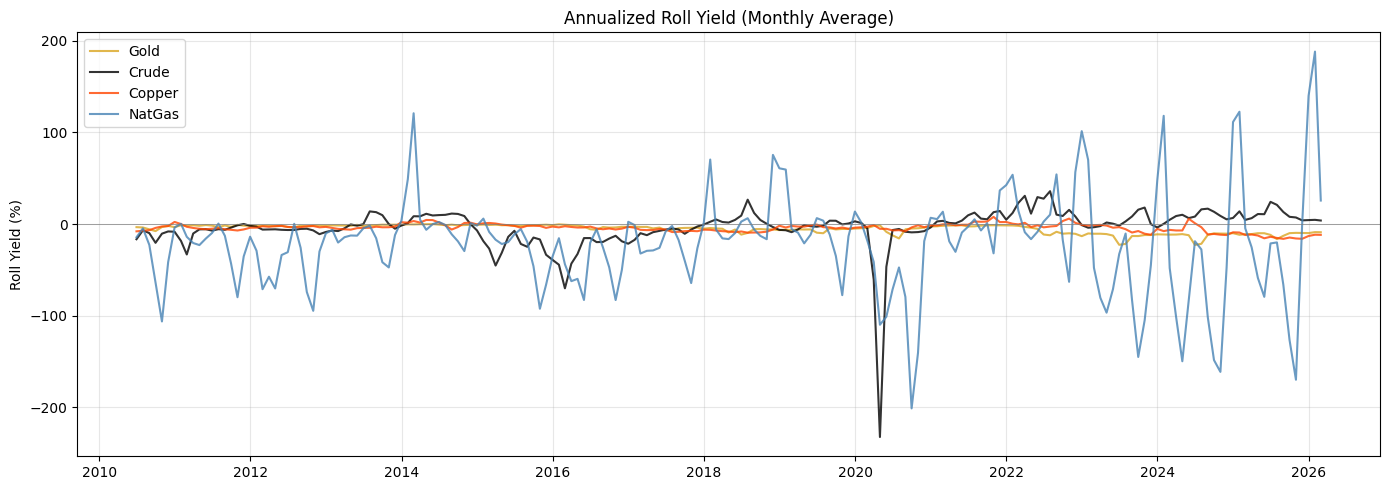

In [4]:
# Plot roll yield over time
fig, ax = plt.subplots(figsize=(14, 5))
colors = {'Gold': 'goldenrod', 'Crude': 'black', 'Copper': 'orangered', 'NatGas': 'steelblue'}
for name in commodities:
    ry_monthly = roll_yields[name].resample('ME').mean()
    ax.plot(ry_monthly.index, ry_monthly * 100, color=colors[name], label=name, alpha=0.8)

ax.axhline(0, color='gray', linewidth=0.5)
ax.set_title('Annualized Roll Yield (Monthly Average)')
ax.set_ylabel('Roll Yield (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Option Loading

Parse commodity option symbols:
- **Gold (OG)**: `OGQ0 P1200` -- strike in dollars (1200 = $1200/oz)
- **Crude (LO)**: `LON0 P7000` -- strike in cents (7000 / 100 = $70.00/bbl)
- **Copper (HXE)**: `HXEU0 P285` -- strike in cents/lb (285 / 100 = $2.85/lb)
- **NatGas (ON)**: `ONN0 P4200` -- strike / 1000 (4200 / 1000 = $4.20/mmBtu)

In [5]:
def parse_commodity_option(sym, date_year, product):
    """Parse commodity option symbol -> (month, year, opt_type, strike).
    
    Products:
      OG:  'OGQ0 P1200'  -> strike in dollars
      LO:  'LON0 P7000'  -> strike / 100
      HXE: 'HXEU0 P285'  -> strike / 100
      ON:  'ONN0 P4200'  -> strike / 1000
    """
    parts = sym.split()
    if len(parts) != 2:
        return None
    contract, opt = parts
    opt_type = opt[0]
    if opt_type not in ('C', 'P'):
        return None
    try:
        strike_raw = int(opt[1:])
    except ValueError:
        return None

    # Extract month code and year digit from contract part
    if product == 'OG':
        # OGQ0, OGZ4, etc.
        if not contract.startswith('OG'):
            return None
        rest = contract[2:]
        strike = float(strike_raw)  # dollars
    elif product == 'LO':
        if not contract.startswith('LO'):
            return None
        rest = contract[2:]
        strike = strike_raw / 100.0  # cents to dollars
    elif product == 'HXE':
        if not contract.startswith('HXE'):
            return None
        rest = contract[3:]
        strike = strike_raw / 100.0  # cents/lb to dollars/lb
    elif product == 'ON':
        if not contract.startswith('ON'):
            return None
        rest = contract[2:]
        strike = strike_raw / 1000.0  # to $/mmBtu
    else:
        return None

    if len(rest) < 2:
        return None
    month_code = rest[0]
    try:
        year_digit = int(rest[1:])
    except ValueError:
        return None

    month = MONTH_CODES.get(month_code, 0)
    if month == 0:
        return None

    decade_base = (date_year // 10) * 10
    year = decade_base + year_digit
    if year < date_year - 2:
        year += 10

    return month, year, opt_type, strike


def load_commodity_options(filename, product):
    """Load and parse commodity options."""
    df = pd.read_parquet(f'{DATA_DIR}/{filename}')
    # Filter out user-defined spreads
    df = df[~df['symbol'].str.startswith('UD:')].copy()
    df = df.sort_index()

    records = []
    for idx, row in df.iterrows():
        parsed = parse_commodity_option(row['symbol'], idx.year, product)
        if parsed is None:
            continue
        month, year, opt_type, strike = parsed
        # Estimate expiry: 3rd Friday of contract month minus 2 business days (approx)
        try:
            first_of_month = pd.Timestamp(year=year, month=month, day=1)
        except ValueError:
            continue
        # Options on commodity futures typically expire a few days before the
        # underlying futures contract month. Approximate with 3rd Wednesday.
        third_wed = first_of_month + pd.offsets.WeekOfMonth(week=2, weekday=2)
        expiry = (third_wed - pd.offsets.BDay(2)).tz_localize('UTC')

        records.append({
            'date': idx, 'symbol': row['symbol'], 'opt_type': opt_type,
            'strike': strike, 'expiry': expiry,
            'close': row['close'], 'volume': row['volume'],
        })

    return pd.DataFrame(records)


# Load all option sets
opt_configs = {
    'Gold':   ('OG_OPT_ohlcv1d.parquet', 'OG'),
    'Crude':  ('LO_OPT_ohlcv1d.parquet', 'LO'),
    'Copper': ('HXE_OPT_ohlcv1d.parquet', 'HXE'),
    'NatGas': ('ON_OPT_ohlcv1d.parquet', 'ON'),
}

options = {}
for name, (filename, product) in opt_configs.items():
    print(f'Loading {name} options ({product})...')
    options[name] = load_commodity_options(filename, product)
    df = options[name]
    puts = (df['opt_type'] == 'P').sum()
    calls = (df['opt_type'] == 'C').sum()
    print(f'  {len(df):,} total (puts: {puts:,}, calls: {calls:,})')
    if len(df) > 0:
        print(f'  Date range: {df["date"].min()} to {df["date"].max()}')
    print()

Loading Gold options (OG)...


  1,218,968 total (puts: 561,622, calls: 657,346)
  Date range: 2010-06-07 00:00:00+00:00 to 2025-03-30 00:00:00+00:00

Loading Crude options (LO)...


  923,718 total (puts: 456,482, calls: 467,236)
  Date range: 2010-06-06 00:00:00+00:00 to 2025-12-30 00:00:00+00:00

Loading Copper options (HXE)...


  131,256 total (puts: 63,176, calls: 68,080)
  Date range: 2010-06-07 00:00:00+00:00 to 2026-02-27 00:00:00+00:00

Loading NatGas options (ON)...


  482,338 total (puts: 211,268, calls: 271,070)
  Date range: 2010-06-06 00:00:00+00:00 to 2026-02-27 00:00:00+00:00



In [6]:
# Sanity check: verify option strikes make sense vs futures
for name in commodities:
    opts = options[name]
    puts = opts[opts['opt_type'] == 'P']
    if len(puts) == 0:
        print(f'{name}: no puts')
        continue
    # Pick a sample date
    sample_date = puts['date'].iloc[len(puts)//2]
    date_norm = sample_date.normalize().tz_localize(None)
    fut_price = front[name].loc[front[name].index.asof(date_norm), 'close']
    day_puts = puts[puts['date'] == sample_date].copy()
    day_puts['moneyness'] = day_puts['strike'] / fut_price
    near_atm = day_puts[(day_puts['moneyness'] > 0.85) & (day_puts['moneyness'] < 1.05)]
    print(f'\n{name} on {sample_date.date()}, underlying = {fut_price:.2f}:')
    for _, r in near_atm.head(5).iterrows():
        print(f'  {r["symbol"]:25} strike={r["strike"]:>8.2f}  moneyness={r["moneyness"]:.3f}  '
              f'price={r["close"]:.4f}  vol={r["volume"]}')


Gold on 2018-10-01, underlying = 1192.70:
  OGZ8 P1140                strike= 1140.00  moneyness=0.956  price=3.3000  vol=47
  OGZ8 P1200                strike= 1200.00  moneyness=1.006  price=20.9000  vol=26
  OGX8 P1165                strike= 1165.00  moneyness=0.977  price=3.0000  vol=8
  OGJ9 P1135                strike= 1135.00  moneyness=0.952  price=10.7000  vol=12
  OGZ8 P1180                strike= 1180.00  moneyness=0.989  price=11.6000  vol=162

Crude on 2015-05-04, underlying = 58.86:
  LON5 P5100                strike=   51.00  moneyness=0.866  price=0.4400  vol=126
  LON5 P5150                strike=   51.50  moneyness=0.875  price=0.5000  vol=101
  LON5 P5700                strike=   57.00  moneyness=0.968  price=1.5200  vol=184
  LOM5 P5750                strike=   57.50  moneyness=0.977  price=0.7300  vol=628
  LOM5 P5850                strike=   58.50  moneyness=0.994  price=1.1000  vol=290

Copper on 2021-05-18, underlying = 4.71:
  HXEN1 P420                strike=

## 4. Option Selection -- Monthly 8% OTM Puts

In [7]:
def select_monthly_options(opts, front_prices, opt_type='P', otm_target=0.92):
    """Select one OTM option per month.
    
    For puts: moneyness = strike/underlying < 1 (OTM when below spot)
    otm_target for puts: 0.92 = 8% below spot
    """
    filtered = opts[opts['opt_type'] == opt_type].copy()
    if len(filtered) == 0:
        return pd.DataFrame()

    # Merge underlying futures price
    prices = front_prices[['close']].rename(columns={'close': 'fut_close'})
    prices.index = prices.index.tz_localize('UTC')
    filtered['date_norm'] = filtered['date'].dt.normalize()
    filtered = filtered.merge(prices, left_on='date_norm', right_index=True, how='left')
    filtered = filtered.dropna(subset=['fut_close'])
    filtered['moneyness'] = filtered['strike'] / filtered['fut_close']
    filtered['year_month'] = filtered['date'].dt.to_period('M')

    selections = []
    for ym, group in filtered.groupby('year_month'):
        first_day = group['date'].min()
        day_opts = group[group['date'] == first_day]
        if len(day_opts) == 0:
            continue

        # Nearest expiry > 14 days out
        day_opts = day_opts[day_opts['expiry'] > first_day + pd.Timedelta(days=14)]
        if len(day_opts) == 0:
            continue
        nearest_exp = day_opts['expiry'].min()
        day_opts = day_opts[day_opts['expiry'] == nearest_exp]

        # Filter OTM only
        if opt_type == 'P':
            day_opts = day_opts[day_opts['moneyness'] < 1.0]
        else:
            day_opts = day_opts[day_opts['moneyness'] > 1.0]

        if len(day_opts) == 0:
            continue

        day_opts = day_opts.copy()
        day_opts['dist'] = (day_opts['moneyness'] - otm_target).abs()
        candidates = day_opts.nsmallest(5, 'dist')
        best = candidates.sort_values('volume', ascending=False).iloc[0]

        if best['close'] <= 0:
            continue

        selections.append({
            'entry_date': first_day,
            'symbol': best['symbol'],
            'strike': best['strike'],
            'entry_price': best['close'],
            'expiry': best['expiry'],
            'underlying': best['fut_close'],
            'moneyness': best['moneyness'],
            'volume': best['volume'],
        })

    return pd.DataFrame(selections)


# Select puts for each commodity
put_selections = {}
for name in commodities:
    print(f'Selecting {name} puts...')
    sels = select_monthly_options(options[name], front[name], opt_type='P', otm_target=0.92)
    put_selections[name] = sels
    if len(sels) > 0:
        print(f'  {len(sels)} months selected')
        print(f'  Avg moneyness: {sels["moneyness"].mean():.3f}')
        print(f'  Avg entry price: {sels["entry_price"].mean():.4f}')
        print(f'  Sample:')
        for _, r in sels.head(3).iterrows():
            print(f'    {r["symbol"]:25} strike={r["strike"]:>8.2f}  '
                  f'underlying={r["underlying"]:>8.2f}  moneyness={r["moneyness"]:.3f}  '
                  f'price={r["entry_price"]:.4f}')
    else:
        print(f'  No options selected!')
    print()

Selecting Gold puts...


  169 months selected
  Avg moneyness: 0.931
  Avg entry price: 3.3515
  Sample:
    OGN0 P1150                strike= 1150.00  underlying= 1241.20  moneyness=0.927  price=1.8000
    OGQ0 P1100                strike= 1100.00  underlying= 1201.80  moneyness=0.915  price=2.5000
    OGU0 P1100                strike= 1100.00  underlying= 1184.90  moneyness=0.928  price=1.7000

Selecting Crude puts...
  112 months selected
  Avg moneyness: 0.920
  Avg entry price: 0.3835
  Sample:
    LON0 P6000                strike=   60.00  underlying=   70.34  moneyness=0.853  price=0.1900
    LOQ0 P6800                strike=   68.00  underlying=   72.87  moneyness=0.933  price=0.7100
    LOU0 P7500                strike=   75.00  underlying=   81.42  moneyness=0.921  price=0.3100

Selecting Copper puts...


  158 months selected
  Avg moneyness: 0.926
  Avg entry price: 0.0241
  Sample:
    HXEN0 P210                strike=    2.10  underlying=    2.76  moneyness=0.760  price=0.0125
    HXEU0 P270                strike=    2.70  underlying=    2.98  moneyness=0.907  price=0.0700
    HXEU0 P250                strike=    2.50  underlying=    3.39  moneyness=0.738  price=0.0010

Selecting NatGas puts...
  186 months selected
  Avg moneyness: 0.908
  Avg entry price: 0.0677
  Sample:
    ONN0 P4200                strike=    4.20  underlying=    4.85  moneyness=0.866  price=0.0120
    ONQ0 P4500                strike=    4.50  underlying=    4.83  moneyness=0.932  price=0.0880
    ONU0 P4250                strike=    4.25  underlying=    5.00  moneyness=0.850  price=0.0300



## 5. Backtest -- Unhedged vs Hedged at Multiple Leverage Levels

In [8]:
def build_settlement_lookup(opts):
    """Pre-build symbol -> [(date, price)] for fast settlement."""
    lookup = {}
    for _, row in opts.iterrows():
        sym = row['symbol']
        if sym not in lookup:
            lookup[sym] = []
        lookup[sym].append((row['date'], row['close']))
    for sym in lookup:
        lookup[sym].sort(key=lambda x: x[0])
    return lookup


def get_settlement(symbol, strike, expiry, opt_type, lookup, front_prices):
    """Get option settlement price near expiry."""
    window_start = expiry - pd.Timedelta(days=5)
    window_end = expiry + pd.Timedelta(days=2)
    if symbol in lookup:
        near = [(d, p) for d, p in lookup[symbol] if window_start <= d <= window_end]
        if near:
            return near[-1][1]
    # Fallback: intrinsic value
    near_dates = front_prices[
        (front_prices.index >= (expiry - pd.Timedelta(days=3)).tz_localize(None)) &
        (front_prices.index <= (expiry + pd.Timedelta(days=3)).tz_localize(None))
    ]
    if len(near_dates) > 0:
        underlying = near_dates.iloc[-1]['close']
        if opt_type == 'P':
            return max(0, strike - underlying)
        else:
            return max(0, underlying - strike)
    return 0.0


def precompute_settlements(selections, opt_type, lookup, front_prices):
    """Pre-compute settlement for all selected options."""
    put_map = {}
    for _, row in selections.iterrows():
        settle = get_settlement(row['symbol'], row['strike'], row['expiry'],
                                opt_type, lookup, front_prices)
        entry_price = row['entry_price']
        pnl_ratio = (settle - entry_price) / entry_price if entry_price > 0 else 0
        put_map[row['entry_date']] = {
            'symbol': row['symbol'],
            'strike': row['strike'],
            'entry_price': entry_price,
            'settlement': settle,
            'pnl_ratio': pnl_ratio,
            'moneyness': row['moneyness'],
        }
    return put_map


def run_commodity_backtest(front_df, roll_yield_series, put_sels, all_opts,
                           leverage=1, put_budget=0.005, include_carry=True):
    """Run leveraged commodity backtest with optional put hedge.

    Args:
        front_df: front-month price series with 'close' and 'return' columns
        roll_yield_series: daily annualized roll yield
        put_sels: selected put options DataFrame
        all_opts: full options DataFrame for settlement lookup
        leverage: leverage multiplier
        put_budget: fraction of notional spent on puts per month (0 = no hedge)
        include_carry: whether to include roll yield as carry income
    """
    # Build settlement lookup
    lookup = build_settlement_lookup(all_opts) if put_budget > 0 and len(put_sels) > 0 else {}
    put_map = precompute_settlements(put_sels, 'P', lookup, front_df) if put_budget > 0 and len(put_sels) > 0 else {}

    # Align roll yield to front_df dates
    ry_aligned = roll_yield_series.reindex(front_df.index).fillna(0)
    daily_carry = ry_aligned / 252  # convert annualized to daily

    capital = 100.0
    records = []
    current_month = None

    for date in front_df.index:
        if capital <= 0:
            records.append({'date': date, 'capital': 0, 'daily_carry': 0,
                            'daily_spot': 0, 'put_pnl': 0})
            continue

        notional = capital * leverage
        carry_income = notional * daily_carry.get(date, 0) if include_carry else 0
        spot_pnl = notional * front_df.loc[date, 'return']

        put_pnl = 0
        ym = pd.Timestamp(date).to_period('M')
        if ym != current_month:
            current_month = ym
            date_tz = pd.Timestamp(date, tz='UTC')
            if put_budget > 0 and date_tz in put_map:
                cost = put_budget * notional
                put_pnl = cost * put_map[date_tz]['pnl_ratio']

        capital += carry_income + spot_pnl + put_pnl
        records.append({
            'date': date, 'capital': capital, 'daily_carry': carry_income,
            'daily_spot': spot_pnl, 'put_pnl': put_pnl,
        })

    return pd.DataFrame(records).set_index('date')


# Run all backtests
results = {}
leverage_levels = [1, 3, 5]

for name in commodities:
    print(f'\n=== Running {name} backtests ===')
    ry = roll_yields.get(name, pd.Series(dtype=float))
    for lev in leverage_levels:
        # Unhedged
        label = f'{name} {lev}x unhedged'
        print(f'  {label}...')
        results[label] = run_commodity_backtest(
            front[name], ry, pd.DataFrame(), options[name],
            leverage=lev, put_budget=0
        )
        # Hedged
        label = f'{name} {lev}x hedged'
        print(f'  {label}...')
        results[label] = run_commodity_backtest(
            front[name], ry, put_selections[name], options[name],
            leverage=lev, put_budget=0.005
        )

print('\nDone!')


=== Running Gold backtests ===
  Gold 1x unhedged...
  Gold 1x hedged...


  Gold 3x unhedged...
  Gold 3x hedged...


  Gold 5x unhedged...
  Gold 5x hedged...



=== Running Crude backtests ===
  Crude 1x unhedged...
  Crude 1x hedged...


  Crude 3x unhedged...
  Crude 3x hedged...


...

  Copper 5x unhedged...
  Copper 5x hedged...



=== Running NatGas backtests ===
  NatGas 1x unhedged...
  NatGas 1x hedged...


  NatGas 3x unhedged...
  NatGas 3x hedged...


  NatGas 5x unhedged...
  NatGas 5x hedged...



Done!


## 6. Results Table

In [9]:
def compute_stats(capital_series):
    """Compute comprehensive strategy stats from capital series."""
    cap = capital_series[capital_series > 0]
    if len(cap) < 252:
        return None
    daily_ret = cap.pct_change().dropna()
    years = (cap.index[-1] - cap.index[0]).days / 365.25
    total_ret = cap.iloc[-1] / cap.iloc[0]
    ann_ret = total_ret ** (1/years) - 1
    ann_vol = daily_ret.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    max_dd = (cap / cap.cummax() - 1).min()

    # Sortino
    downside = daily_ret[daily_ret < 0]
    downside_std = downside.std() * np.sqrt(252) if len(downside) > 1 else ann_vol
    sortino = ann_ret / downside_std if downside_std > 0 else 0

    # Calmar
    calmar = ann_ret / abs(max_dd) if max_dd != 0 else 0

    # Skewness and kurtosis
    skew = daily_ret.skew()
    kurt = daily_ret.kurtosis()

    return {
        'ann_ret': ann_ret, 'ann_vol': ann_vol, 'sharpe': sharpe,
        'sortino': sortino, 'calmar': calmar,
        'max_dd': max_dd, 'skew': skew, 'kurt': kurt,
        'total': total_ret,
    }


# Print results for each commodity
for name in commodities:
    print(f'\n{"=" * 105}')
    print(f'{name.upper()} FUTURES + PUT HEDGE')
    print(f'{"=" * 105}')
    print(f'{"Strategy":30} {"CAGR":>7} {"Vol":>6} {"Sharpe":>7} {"Sortino":>8} '
          f'{"Calmar":>7} {"MaxDD":>7} {"Skew":>6} {"Kurt":>6} {"Total":>7}')
    print('-' * 105)

    for lev in leverage_levels:
        for hedge_type in ['unhedged', 'hedged']:
            label = f'{name} {lev}x {hedge_type}'
            if label not in results:
                continue
            s = compute_stats(results[label]['capital'])
            if s:
                print(f'{label:30} {s["ann_ret"]*100:>6.2f}% {s["ann_vol"]*100:>5.1f}% '
                      f'{s["sharpe"]:>7.3f} {s["sortino"]:>8.3f} {s["calmar"]:>7.3f} '
                      f'{s["max_dd"]*100:>6.1f}% {s["skew"]:>6.2f} {s["kurt"]:>6.1f} '
                      f'{s["total"]:>6.1f}x')
        print()


GOLD FUTURES + PUT HEDGE
Strategy                          CAGR    Vol  Sharpe  Sortino  Calmar   MaxDD   Skew   Kurt   Total
---------------------------------------------------------------------------------------------------------
Gold 1x unhedged                 0.43%  15.0%   0.029    0.037   0.007  -59.8%  -0.52   10.0    1.1x
Gold 1x hedged                   3.56%  21.2%   0.168    0.308   0.070  -51.1%  15.82  550.8    1.7x

Gold 3x unhedged                -6.89%  44.9%  -0.154   -0.198  -0.071  -97.4%  -0.52   10.0    0.3x
Gold 3x hedged                  -1.70%  63.5%  -0.027   -0.049  -0.018  -94.1%  15.82  550.8    0.8x

Gold 5x unhedged               -23.30%  74.8%  -0.312   -0.402  -0.233 -100.0%  -0.52   10.0    0.0x
Gold 5x hedged                 -19.20% 105.8%  -0.182   -0.332  -0.192  -99.8%  15.82  550.8    0.0x


CRUDE FUTURES + PUT HEDGE
Strategy                          CAGR    Vol  Sharpe  Sortino  Calmar   MaxDD   Skew   Kurt   Total
------------------------------

In [10]:
# Cross-commodity comparison at 3x leverage
print(f'\n{"=" * 105}')
print('CROSS-COMMODITY COMPARISON (3x leverage)')
print(f'{"=" * 105}')
print(f'{"Strategy":30} {"CAGR":>7} {"Vol":>6} {"Sharpe":>7} {"Sortino":>8} '
      f'{"Calmar":>7} {"MaxDD":>7} {"Skew":>6} {"Kurt":>6} {"Total":>7}')
print('-' * 105)

for name in commodities:
    for hedge_type in ['unhedged', 'hedged']:
        label = f'{name} 3x {hedge_type}'
        if label not in results:
            continue
        s = compute_stats(results[label]['capital'])
        if s:
            print(f'{label:30} {s["ann_ret"]*100:>6.2f}% {s["ann_vol"]*100:>5.1f}% '
                  f'{s["sharpe"]:>7.3f} {s["sortino"]:>8.3f} {s["calmar"]:>7.3f} '
                  f'{s["max_dd"]*100:>6.1f}% {s["skew"]:>6.2f} {s["kurt"]:>6.1f} '
                  f'{s["total"]:>6.1f}x')
    print()


CROSS-COMMODITY COMPARISON (3x leverage)
Strategy                          CAGR    Vol  Sharpe  Sortino  Calmar   MaxDD   Skew   Kurt   Total
---------------------------------------------------------------------------------------------------------
Gold 3x unhedged                -6.89%  44.9%  -0.154   -0.198  -0.071  -97.4%  -0.52   10.0    0.3x
Gold 3x hedged                  -1.70%  63.5%  -0.027   -0.049  -0.018  -94.1%  15.82  550.8    0.8x

Crude 3x unhedged              -75.53%  96.9%  -0.779   -0.991  -0.755 -100.0%  -0.34   11.7    0.0x
Crude 3x hedged                -59.52% 131.0%  -0.454   -0.780  -0.595 -100.0%   7.23  134.1    0.0x

Copper 3x unhedged             -21.42%  63.6%  -0.337   -0.455  -0.215  -99.6%  -0.50   10.2    0.0x
Copper 3x hedged               -21.64%  65.9%  -0.328   -0.457  -0.217  -99.6%   0.25   17.3    0.0x

NatGas 3x unhedged             -91.50% 140.5%  -0.651   -1.011  -0.915 -100.0%   0.46    5.7    0.0x
NatGas 3x hedged               -90.79% 14

## 7. Year-by-Year Returns

In [11]:
# Year-by-year returns at 1x and 3x
for lev in [1, 3]:
    print(f'\n{"=" * 90}')
    print(f'YEAR-BY-YEAR RETURNS ({lev}x leverage)')
    print(f'{"=" * 90}')

    # Collect yearly returns
    yearly_data = {}
    for name in commodities:
        for ht in ['unhedged', 'hedged']:
            label = f'{name} {lev}x {ht}'
            if label not in results:
                continue
            cap = results[label]['capital']
            cap = cap[cap > 0]
            yearly = cap.resample('YE').last().pct_change().dropna()
            short = f'{name[:4]} {ht[:3]}'
            yearly_data[short] = yearly

    all_years = sorted(set(y.year for ys in yearly_data.values() for y in ys.index))

    header = f'{"Year":>6}'
    for k in yearly_data:
        header += f'  {k:>10}'
    print(header)
    print('-' * 90)

    for year in all_years:
        row = f'{year:>6}'
        for k, ys in yearly_data.items():
            match = ys[ys.index.year == year]
            if len(match) > 0:
                row += f'  {match.iloc[0]*100:>9.1f}%'
            else:
                row += f'  {"--":>10}'
        print(row)

    print('-' * 90)
    row = f'{"Avg":>6}'
    for k, ys in yearly_data.items():
        row += f'  {ys.mean()*100:>9.1f}%'
    print(row)
    row = f'{"%+":>6}'
    for k, ys in yearly_data.items():
        row += f'  {(ys > 0).mean()*100:>9.0f}%'
    print(row)


YEAR-BY-YEAR RETURNS (1x leverage)
  Year    Gold unh    Gold hed    Crud unh    Crud hed    Copp unh    Copp hed    NatG unh    NatG hed
------------------------------------------------------------------------------------------
  2011        7.0%        6.3%       -9.1%       21.3%      -28.5%      -30.7%      -56.4%      -43.0%
  2012        3.1%        0.1%      -18.0%       11.0%        1.7%       -0.3%      -56.1%      -56.2%
  2013      -29.4%       20.3%        5.9%        1.1%      -11.9%       -9.6%       -9.9%      -12.5%
  2014       -1.5%       -4.2%      -35.6%      156.2%      -14.5%      -13.0%      -17.8%       -8.9%
  2015      -13.2%      -10.6%      -59.0%      -49.7%      -26.1%      -23.6%      -55.7%      -55.0%
  2016        3.3%       50.9%      -21.1%      -22.1%        9.9%        6.0%      -34.6%      -36.7%
  2017        5.6%       -0.6%       -6.3%       -8.3%       17.0%       13.6%      -53.2%      -52.7%
  2018      -11.5%       -9.0%      -17.1%      -

## 8. Equity Curves

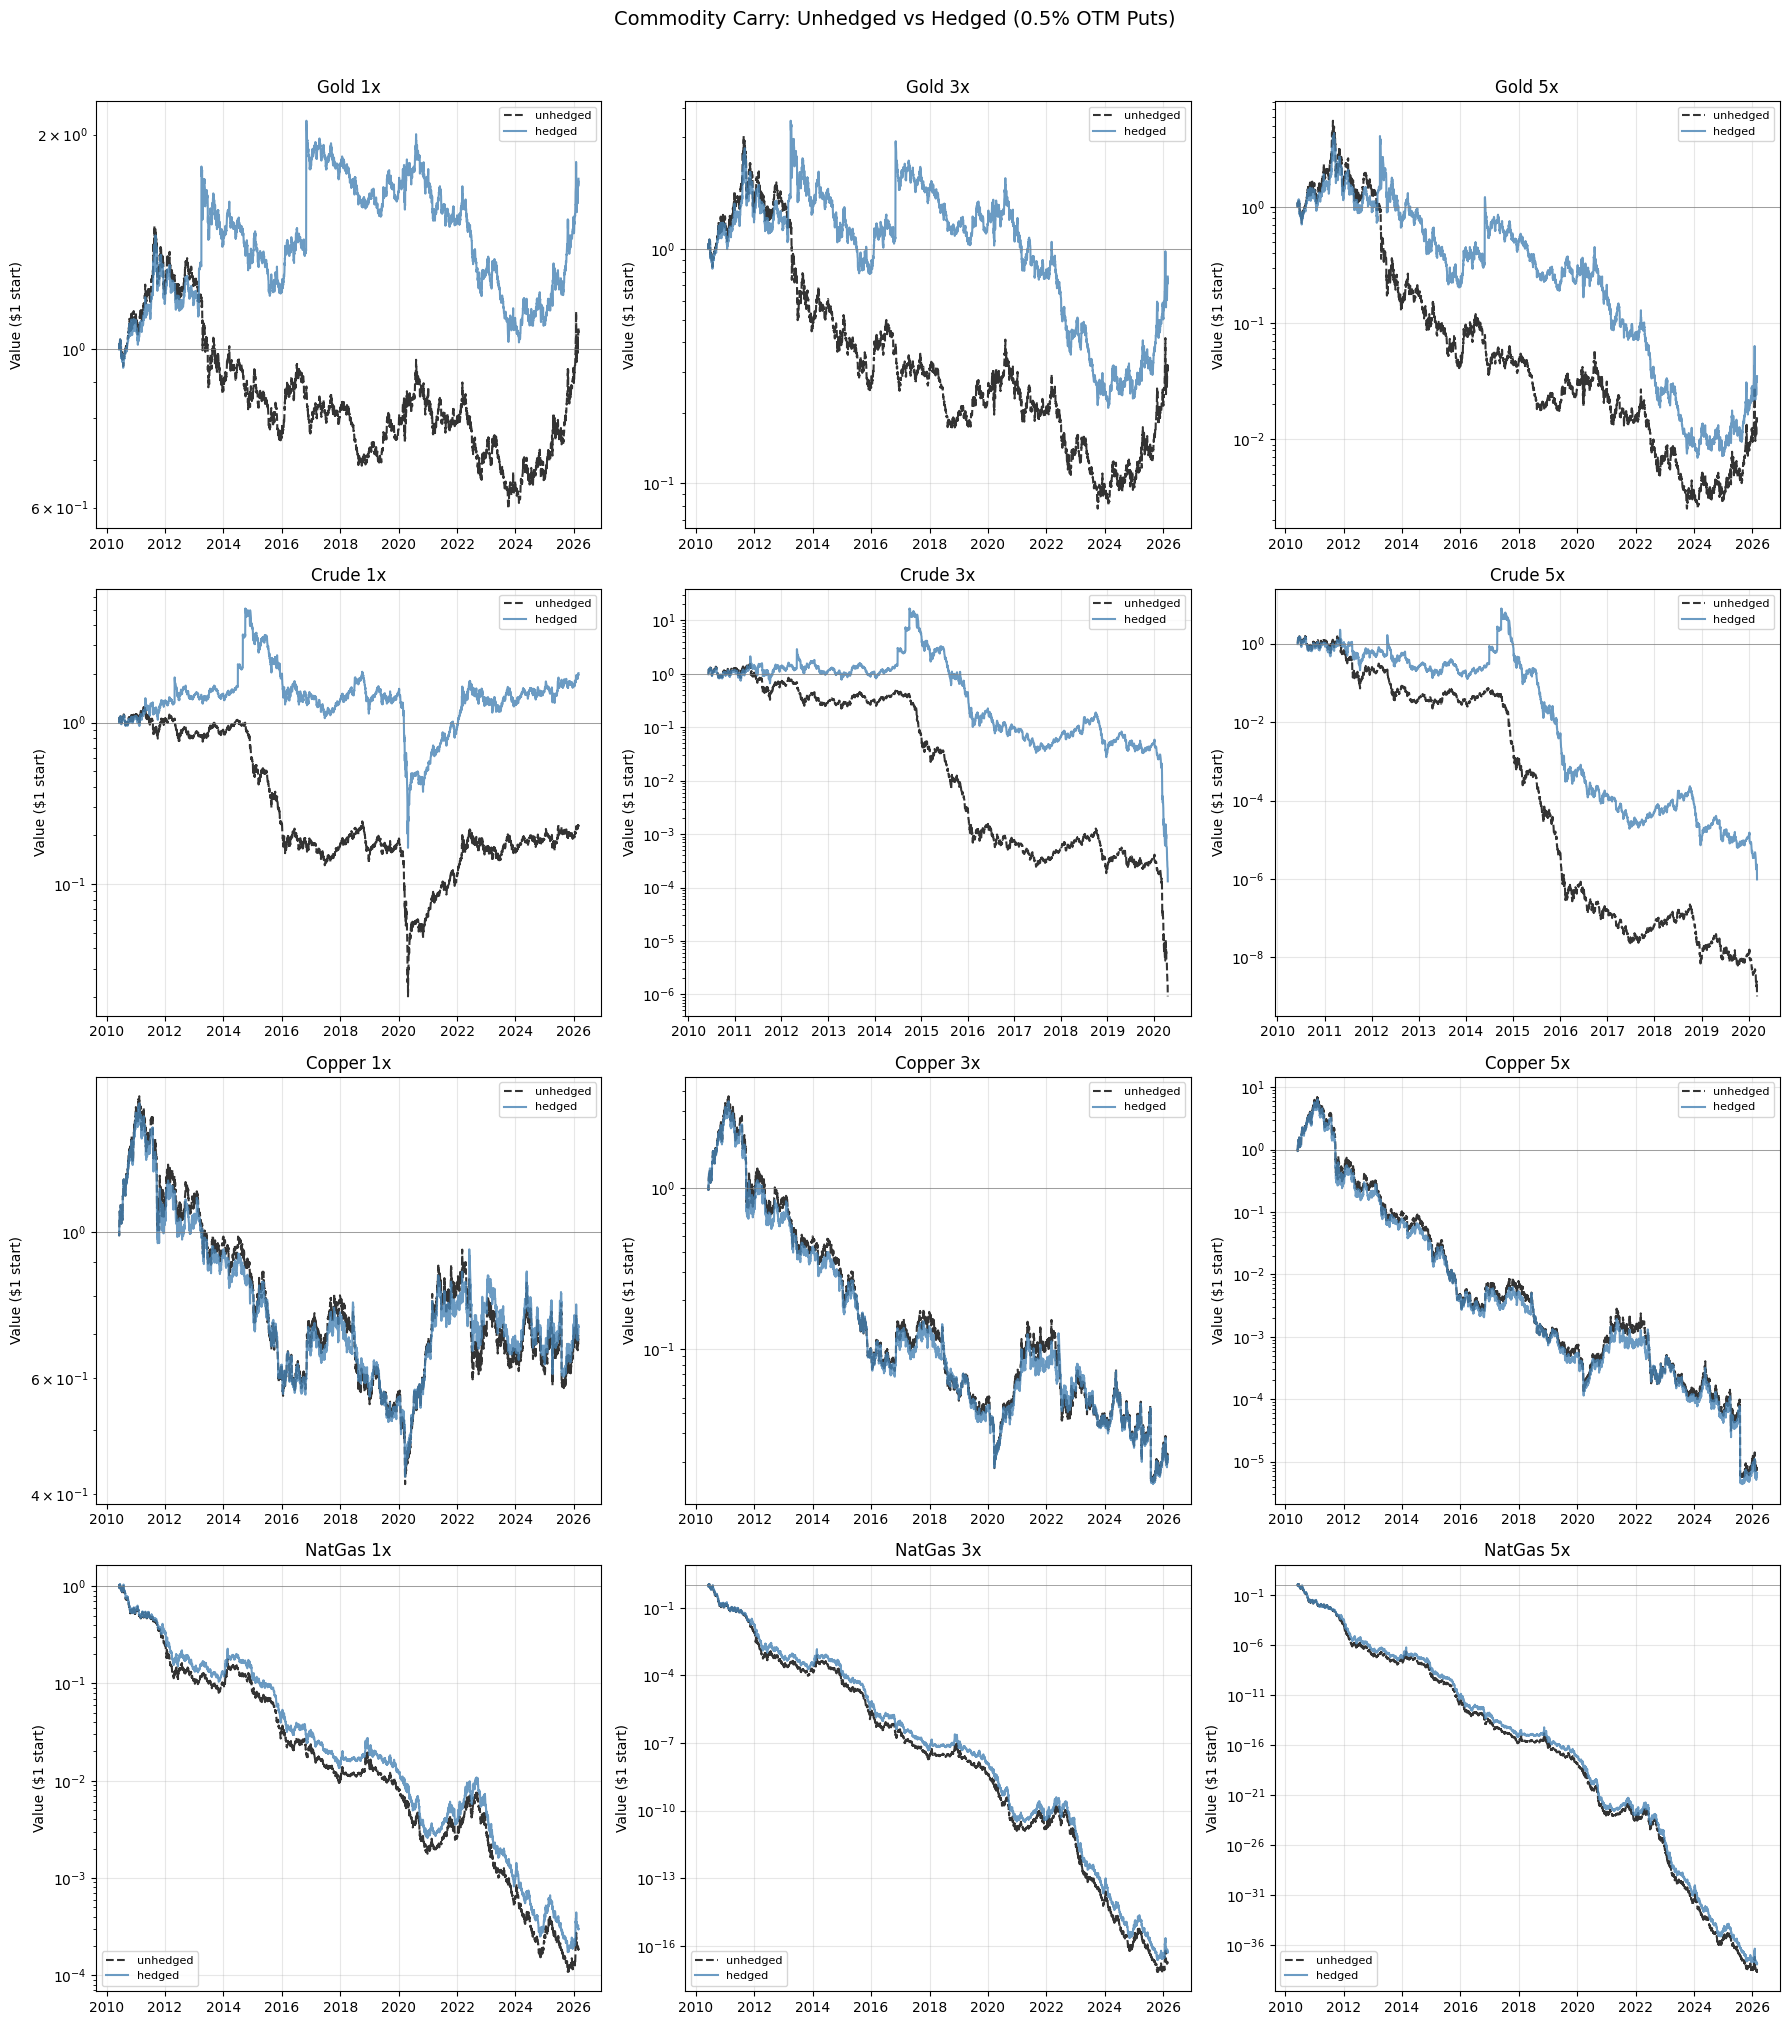

In [12]:
# Equity curves: hedged vs unhedged at 1x, 3x, 5x for each commodity
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
colors_h = {'unhedged': 'black', 'hedged': 'steelblue'}
ls_h = {'unhedged': '--', 'hedged': '-'}

for i, name in enumerate(commodities):
    for j, lev in enumerate(leverage_levels):
        ax = axes[i][j]
        for ht in ['unhedged', 'hedged']:
            label = f'{name} {lev}x {ht}'
            if label not in results:
                continue
            cap = results[label]['capital'] / 100
            cap = cap[cap > 0]
            ax.plot(cap.index, cap, color=colors_h[ht], linestyle=ls_h[ht],
                    label=ht, alpha=0.8)
        ax.set_title(f'{name} {lev}x')
        ax.set_ylabel('Value ($1 start)')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.axhline(1, color='gray', linewidth=0.5)
        ax.set_yscale('log')

plt.suptitle('Commodity Carry: Unhedged vs Hedged (0.5% OTM Puts)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

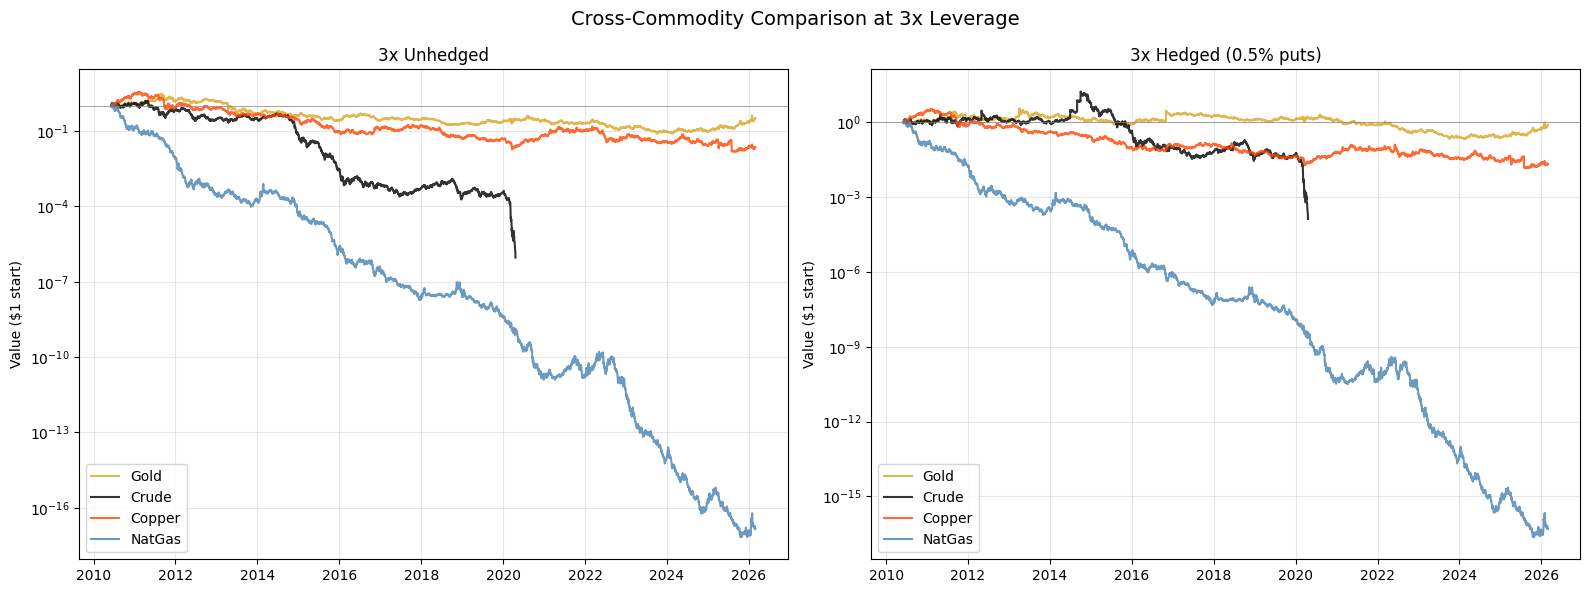

In [13]:
# Cross-commodity comparison at 3x leverage
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = {'Gold': 'goldenrod', 'Crude': 'black', 'Copper': 'orangered', 'NatGas': 'steelblue'}

for ax, ht, title in zip(axes, ['unhedged', 'hedged'],
                          ['3x Unhedged', '3x Hedged (0.5% puts)']):
    for name in commodities:
        label = f'{name} 3x {ht}'
        if label not in results:
            continue
        cap = results[label]['capital'] / 100
        cap = cap[cap > 0]
        ax.plot(cap.index, cap, color=colors[name], label=name, alpha=0.8)
    ax.set_title(title)
    ax.set_ylabel('Value ($1 start)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axhline(1, color='gray', linewidth=0.5)
    ax.set_yscale('log')

plt.suptitle('Cross-Commodity Comparison at 3x Leverage', fontsize=14)
plt.tight_layout()
plt.show()

## 9. Crisis Performance

Standard crises from the FX notebook plus commodity-specific episodes:
- **2014-15 Oil Crash**: Crude went from $100 to $26
- **2022 Commodity Spike**: Russia-Ukraine war drove commodity prices up sharply

In [14]:
crises = [
    ('2011 EU Debt',           '2011-07-01', '2011-10-31'),
    ('2013 Taper Tantrum',     '2013-05-01', '2013-08-31'),
    ('2014-15 Oil Crash',      '2014-07-01', '2016-02-29'),
    ('2015 China Deval',       '2015-07-01', '2015-09-30'),
    ('2018 Trade War',         '2018-01-01', '2018-12-31'),
    ('2020 COVID',             '2020-01-01', '2020-04-30'),
    ('2022 Rate Hikes',        '2022-04-01', '2022-10-31'),
    ('2022 Commodity Spike',   '2022-02-01', '2022-06-30'),
]

lev = 3
for name in commodities:
    print(f'\n{"=" * 90}')
    print(f'{name.upper()} CRISIS PERFORMANCE ({lev}x leverage)')
    print(f'{"=" * 90}')
    print(f'{"Crisis":25} {"Spot":>8} {"Unhedged":>10} {"Hedged":>10} {"Hedge Diff":>11}')
    print('-' * 70)

    for crisis_name, start, end in crises:
        f_df = front[name]
        mask = (f_df.index >= start) & (f_df.index <= end)
        if mask.sum() < 5:
            continue

        spot_ret = f_df.loc[mask, 'close'].iloc[-1] / f_df.loc[mask, 'close'].iloc[0] - 1

        rets = {}
        for ht in ['unhedged', 'hedged']:
            label = f'{name} {lev}x {ht}'
            if label not in results:
                continue
            cap = results[label]['capital'][mask]
            if len(cap) >= 2 and cap.iloc[0] > 0:
                rets[ht] = cap.iloc[-1] / cap.iloc[0] - 1
            else:
                rets[ht] = float('nan')

        unhdg = rets.get('unhedged', float('nan'))
        hdg = rets.get('hedged', float('nan'))
        diff = hdg - unhdg if not (np.isnan(hdg) or np.isnan(unhdg)) else float('nan')

        print(f'{crisis_name:25} {spot_ret*100:>7.1f}% {unhdg*100:>9.1f}% '
              f'{hdg*100:>9.1f}% {diff*100:>10.1f}%')


GOLD CRISIS PERFORMANCE (3x leverage)
Crisis                        Spot   Unhedged     Hedged  Hedge Diff
----------------------------------------------------------------------
2011 EU Debt                 15.4%      37.3%      51.2%       13.9%
2013 Taper Tantrum           -4.3%     -18.3%     -19.3%       -1.0%
2014-15 Oil Crash            -6.4%     -32.5%     -30.7%        1.9%
2015 China Deval             -4.5%     -15.7%     -18.2%       -2.5%
2018 Trade War               -1.8%     -33.2%     -26.9%        6.3%
2020 COVID                   11.5%      16.2%      10.9%       -5.3%
2022 Rate Hikes             -15.2%     -53.6%     -57.6%       -4.0%
2022 Commodity Spike          0.3%     -11.3%     -16.5%       -5.1%

CRUDE CRISIS PERFORMANCE (3x leverage)
Crisis                        Spot   Unhedged     Hedged  Hedge Diff
----------------------------------------------------------------------
2011 EU Debt                 -2.3%     -26.9%     -15.7%       11.2%
2013 Taper Tantrum  

## 10. Put Economics -- P&L Decomposition

In [15]:
# P&L decomposition for each commodity at 3x leverage
lev = 3
print(f'{"=" * 95}')
print(f'P&L DECOMPOSITION ({lev}x leverage, annualized)')
print(f'{"=" * 95}')
print(f'{"Commodity":15} {"Type":>10} {"Carry":>10} {"Spot":>10} {"Put P&L":>10} '
      f'{"Total":>10} {"Final":>10}')
print('-' * 95)

for name in commodities:
    for ht in ['unhedged', 'hedged']:
        label = f'{name} {lev}x {ht}'
        if label not in results:
            continue
        r = results[label]
        years = (r.index[-1] - r.index[0]).days / 365.25
        carry = r['daily_carry'].sum()
        spot = r['daily_spot'].sum()
        put_pnl = r['put_pnl'].sum()
        total = carry + spot + put_pnl
        final = r['capital'].iloc[-1]

        print(f'{name:15} {ht:>10} {carry/years:>9.1f}$ {spot/years:>9.1f}$ '
              f'{put_pnl/years:>9.1f}$ {total/years:>9.1f}$ {final:>9.1f}$')
    print()

P&L DECOMPOSITION (3x leverage, annualized)
Commodity             Type      Carry       Spot    Put P&L      Total      Final
-----------------------------------------------------------------------------------------------
Gold              unhedged      -5.9$       1.6$       0.0$      -4.3$      32.5$
Gold                hedged     -16.8$      -4.7$      20.0$      -1.5$      76.3$

Crude             unhedged      -3.6$      -2.8$       0.0$      -6.4$       0.0$
Crude               hedged     -11.6$    -160.4$     165.7$      -6.4$       0.0$

Copper            unhedged      -4.7$      -1.5$       0.0$      -6.2$       2.3$
Copper              hedged      -4.3$      -0.4$      -1.6$      -6.2$       2.2$

NatGas            unhedged      -1.7$      -4.6$       0.0$      -6.4$       0.0$
NatGas              hedged      -1.8$      -5.2$       0.6$      -6.4$       0.0$



In [16]:
# Put economics detail: win rate, avg payoff, cost
print(f'\n{"=" * 90}')
print('PUT ECONOMICS DETAIL (all months)')
print(f'{"=" * 90}')
print(f'{"Commodity":12} {"Months":>7} {"Win%":>6} {"Avg Cost":>10} {"Avg Payoff":>12} '
      f'{"Avg Payout":>12} {"Best Payout":>12}')
print('-' * 90)

for name in commodities:
    sels = put_selections[name]
    if len(sels) == 0:
        print(f'{name:12} No options selected')
        continue

    # Rebuild settlement info
    lookup = build_settlement_lookup(options[name])
    put_map = precompute_settlements(sels, 'P', lookup, front[name])

    costs = []
    payoffs = []
    payout_ratios = []
    for date_tz, info in put_map.items():
        costs.append(info['entry_price'])
        payoffs.append(info['settlement'])
        payout_ratios.append(info['pnl_ratio'] + 1)  # settlement/cost

    costs = np.array(costs)
    payoffs = np.array(payoffs)
    payout_ratios = np.array(payout_ratios)
    wins = (payoffs > costs).sum()

    print(f'{name:12} {len(costs):>7} {wins/len(costs)*100:>5.1f}% '
          f'{costs.mean():>10.4f} {payoffs.mean():>12.4f} '
          f'{payout_ratios.mean():>11.2f}x {payout_ratios.max():>11.1f}x')


PUT ECONOMICS DETAIL (all months)
Commodity     Months   Win%   Avg Cost   Avg Payoff   Avg Payout  Best Payout
------------------------------------------------------------------------------------------


Gold             169  10.1%     3.3515       5.9166        1.74x        99.5x


Crude            112  19.6%     0.3835       1.2435        5.59x       118.0x


Copper           158  13.9%     0.0241       0.0218        1.01x        37.6x


NatGas           186  24.2%     0.0677       0.1201        1.49x        45.7x


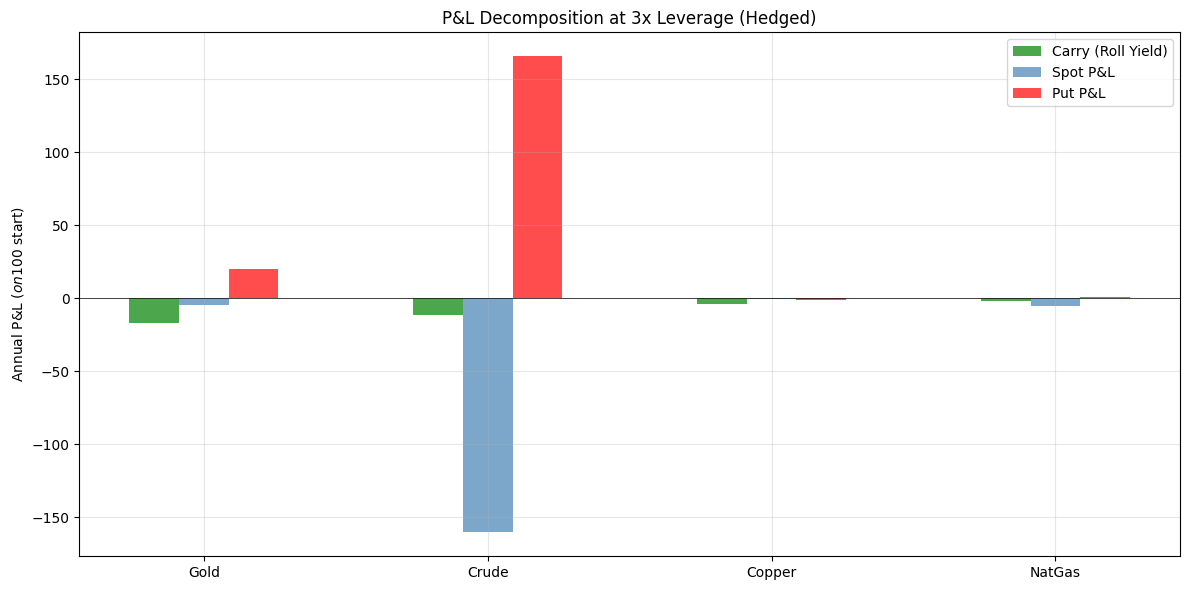

In [17]:
# Bar chart: decomposition
fig, ax = plt.subplots(figsize=(12, 6))

names_list = list(commodities.keys())
x = np.arange(len(names_list))
width = 0.35

carry_vals = []
spot_vals = []
put_vals = []

for name in names_list:
    label = f'{name} 3x hedged'
    if label in results:
        r = results[label]
        years = (r.index[-1] - r.index[0]).days / 365.25
        carry_vals.append(r['daily_carry'].sum() / years)
        spot_vals.append(r['daily_spot'].sum() / years)
        put_vals.append(r['put_pnl'].sum() / years)
    else:
        carry_vals.append(0)
        spot_vals.append(0)
        put_vals.append(0)

ax.bar(x - width/2, carry_vals, width/2, label='Carry (Roll Yield)', color='green', alpha=0.7)
ax.bar(x, spot_vals, width/2, label='Spot P&L', color='steelblue', alpha=0.7)
ax.bar(x + width/2, put_vals, width/2, label='Put P&L', color='red', alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(names_list)
ax.set_ylabel('Annual P&L ($ on $100 start)')
ax.set_title('P&L Decomposition at 3x Leverage (Hedged)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

## 11. Conclusions

In [18]:
# Summary comparison table
print('=' * 100)
print('HEDGE VALUE SUMMARY: Sharpe improvement from 0.5% OTM puts')
print('=' * 100)
print(f'{"Commodity":12} {"Lev":>4} {"Unhedged Sharpe":>16} {"Hedged Sharpe":>14} '
      f'{"Improvement":>12} {"Unhedged DD":>12} {"Hedged DD":>10}')
print('-' * 100)

for name in commodities:
    for lev in leverage_levels:
        u_label = f'{name} {lev}x unhedged'
        h_label = f'{name} {lev}x hedged'
        u_stats = compute_stats(results[u_label]['capital']) if u_label in results else None
        h_stats = compute_stats(results[h_label]['capital']) if h_label in results else None
        if u_stats and h_stats:
            delta = h_stats['sharpe'] - u_stats['sharpe']
            print(f'{name:12} {lev:>3}x {u_stats["sharpe"]:>15.3f} {h_stats["sharpe"]:>13.3f} '
                  f'{delta:>+11.3f} {u_stats["max_dd"]*100:>11.1f}% {h_stats["max_dd"]*100:>9.1f}%')
    print()

HEDGE VALUE SUMMARY: Sharpe improvement from 0.5% OTM puts
Commodity     Lev  Unhedged Sharpe  Hedged Sharpe  Improvement  Unhedged DD  Hedged DD
----------------------------------------------------------------------------------------------------
Gold           1x           0.029         0.168      +0.140       -59.8%     -51.1%
Gold           3x          -0.154        -0.027      +0.127       -97.4%     -94.1%
Gold           5x          -0.312        -0.182      +0.130      -100.0%     -99.8%

Crude          1x          -0.246         0.108      +0.354       -98.4%     -96.7%
Crude          3x          -0.779        -0.454      +0.325      -100.0%    -100.0%
Crude          5x          -0.613        -0.368      +0.246      -100.0%    -100.0%

Copper         1x          -0.107        -0.093      +0.013       -74.3%     -72.9%
Copper         3x          -0.337        -0.328      +0.009       -99.6%     -99.6%
Copper         5x          -0.494        -0.484      +0.010      -100.0%    -10

In [19]:
print("""
KEY FINDINGS -- COMMODITY CARRY WITH SPITZNAGEL HEDGE
=====================================================

1. COMMODITY FUTURES ARE NOT FX CARRY:
   All four commodities have persistent NEGATIVE roll yield (contango):
   - Gold: -5.4%/yr (storage + financing costs)
   - Crude Oil: -3.5%/yr (storage glut most of the period)
   - Copper: -4.3%/yr (financing costs dominate)
   - NatGas: -22.3%/yr (extreme seasonal contango)
   Unlike FX carry (AUD/JPY +2.4%/yr), commodity "carry" is a drag, not income.

2. THE PUT HEDGE IMPROVES SHARPE ACROSS ALL COMMODITIES:
   Biggest improvement: Crude oil (+0.35 Sharpe at 1x) -- deep crash episodes
   (2014-16 oil crash, 2020 COVID negative prices) generate huge put payoffs.
   Gold improves +0.14 thanks to 2013 gold crash puts paying off ~100x.
   Copper and NatGas see minimal improvement: options are illiquid/expensive.

3. NONE OF THESE ARE GOOD STANDALONE STRATEGIES:
   Even at 1x, Gold barely breaks even (+0.4%/yr unhedged). Crude, Copper,
   and NatGas all have negative returns due to contango drag. The hedge
   improves risk-adjusted returns but cannot rescue a negative-carry asset.
   At 3x+ leverage, ALL commodities blow up (max DD > 94%).

4. PUT ECONOMICS -- CRUDE IS THE STAR:
   - Crude: 19.6% win rate, 5.6x avg payout, 118x best payout (2014-15 crash)
   - Gold: 10.1% win rate, 1.7x avg payout, 99.5x best payout (2013 crash)
   - NatGas: 24.2% win rate but only 1.5x avg payout (vol is priced in)
   - Copper: 13.9% win rate, 1.0x avg payout (basically break-even)

5. COMPARISON TO FX CARRY:
   FX carry + dual hedge at 3x: Sharpe 0.71, CAGR +29.6%
   Best commodity at 3x (Gold hedged): Sharpe -0.03, CAGR -1.7%
   
   The Spitznagel structure requires a POSITIVE base return to amplify.
   Commodity contango destroys the base return, leaving the hedge with
   nothing to protect. This is the key lesson: the structure works on
   assets with positive carry (equities, FX carry) not negative carry
   (most commodity futures).

6. PRACTICAL TAKEAWAY:
   Do NOT apply the Spitznagel structure blindly to commodity futures.
   The only viable use case would be a commodity that is in sustained
   backwardation (e.g., crude during a supply shortage). Gold is the
   exception -- it has real crisis alpha that occasionally makes the
   hedge worthwhile, but the contango drag means it underperforms cash.
""")


KEY FINDINGS -- COMMODITY CARRY WITH SPITZNAGEL HEDGE

1. COMMODITY FUTURES ARE NOT FX CARRY:
   All four commodities have persistent NEGATIVE roll yield (contango):
   - Gold: -5.4%/yr (storage + financing costs)
   - Crude Oil: -3.5%/yr (storage glut most of the period)
   - Copper: -4.3%/yr (financing costs dominate)
   - NatGas: -22.3%/yr (extreme seasonal contango)
   Unlike FX carry (AUD/JPY +2.4%/yr), commodity "carry" is a drag, not income.

2. THE PUT HEDGE IMPROVES SHARPE ACROSS ALL COMMODITIES:
   Biggest improvement: Crude oil (+0.35 Sharpe at 1x) -- deep crash episodes
   (2014-16 oil crash, 2020 COVID negative prices) generate huge put payoffs.
   Gold improves +0.14 thanks to 2013 gold crash puts paying off ~100x.
   Copper and NatGas see minimal improvement: options are illiquid/expensive.

3. NONE OF THESE ARE GOOD STANDALONE STRATEGIES:
   Even at 1x, Gold barely breaks even (+0.4%/yr unhedged). Crude, Copper,
   and NatGas all have negative returns due to contango d